# WP3 — Partie 3 : Améliorations anti-overfitting

### 3.1 Chargement et prétraitement des paires

On normalise `z_full` avec la moyenne et l'écart-type du train set.
Cela centre les données et stabilise l'entraînement — important car `z_full` n'est pas normalisé contrairement à `z_clip` (L2-normalisé par CLIP).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

data_train = torch.load('pairs_train.pt')
data_val = torch.load('pairs_val.pt')

# Normalisation de z_full : mean/std calcules sur le train uniquement
# On applique ensuite les memes stats au val pour eviter le data leakage
z_full_mean = data_train['z_full'].mean(dim=0)  # (1024,)
z_full_std = data_train['z_full'].std(dim=0).clamp(min=1e-6)  # (1024,)

z_full_train_norm = (data_train['z_full'] - z_full_mean) / z_full_std
z_full_val_norm = (data_val['z_full'] - z_full_mean) / z_full_std

# Sauvegarder les stats pour l'inference ulterieure
torch.save({'mean': z_full_mean, 'std': z_full_std}, 'z_full_norm_stats.pt')

print(f'z_full avant normalisation — mean: {data_train["z_full"].mean():.4f}, std: {data_train["z_full"].std():.4f}')
print(f'z_full apres normalisation — mean: {z_full_train_norm.mean():.4f}, std: {z_full_train_norm.std():.4f}')

train_ds = TensorDataset(z_full_train_norm, data_train['z_clip'])
val_ds = TensorDataset(z_full_val_norm, data_val['z_clip'])

BATCH_SIZE = 512
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds)} paires')
print(f'Val   : {len(val_ds)} paires')

Device : cpu
z_full avant normalisation — mean: -0.0152, std: 0.5665
z_full apres normalisation — mean: -0.0000, std: 1.0000
Train : 117000 paires
Val   : 13000 paires


### 3.2 Architecture améliorée

Trois changements par rapport au baseline :
- **Dropout** : régularisation directe contre l'overfitting
- **hidden_dim=1024** : capacité maintenue pour 117 000 exemples d'entraînement, le dropout assure la régularisation
- **BatchNorm** en entrée : normalise le batch à chaque forward pass, complémentaire à la normalisation globale

In [2]:
class ProjectionMLPv2(nn.Module):
    """
    MLP ameliore avec Dropout, BatchNorm et capacite adaptee a 117k exemples.

    Changements vs baseline :
    - BatchNorm1d en entree : normalise les activations par batch
    - hidden_dim=1024 : capacite adaptee au volume de donnees (117k paires)
    - Dropout(0.2) : regularisation sans trop contraindre le modele
    """
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),       # normalise les z_full par batch
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


model = ProjectionMLPv2().to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parametres : {n_params:,}')

ProjectionMLPv2(
  (net): Sequential(
    (0): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=1024, out_features=1024, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
    (4): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (5): Linear(in_features=1024, out_features=768, bias=True)
  )
)
Parametres : 1,840,896


### 3.3 Loss et entraînement avec early stopping

In [3]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

def projection_loss(z_mae, z_clip):
    return (1 - F.cosine_similarity(z_mae, z_clip)).mean()


N_EPOCHS = 200
LR = 3e-4   # reduit vs baseline (1e-3 causait un pic precoce a epoch 14)
WEIGHT_DECAY = 1e-3
PATIENCE = 25     # early stopping

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'val_cos_sim': []}
best_cos, best_epoch, patience_counter = 0., 0, 0


def eval_epoch(loader):
    model.eval()
    total_loss, total_cos, n = 0., 0., 0
    with torch.no_grad():
        for z_full, z_clip in loader:
            z_full, z_clip = z_full.to(DEVICE), z_clip.to(DEVICE)
            z_proj = model(z_full)
            loss = projection_loss(z_proj, z_clip)
            cos = F.cosine_similarity(z_proj, z_clip).mean()
            B = z_full.shape[0]
            total_loss += loss.item() * B
            total_cos += cos.item() * B
            n += B
    return total_loss / n, total_cos / n


for epoch in range(N_EPOCHS):
    model.train()
    total_loss, n = 0., 0
    for z_full, z_clip in train_loader:
        z_full, z_clip = z_full.to(DEVICE), z_clip.to(DEVICE)
        optimizer.zero_grad()
        z_proj = model(z_full)
        loss = projection_loss(z_proj, z_clip)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * z_full.shape[0]
        n += z_full.shape[0]
    scheduler.step()

    train_loss = total_loss / n
    val_loss, val_cos = eval_epoch(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cos_sim'].append(val_cos)

    if val_cos > best_cos:
        best_cos, best_epoch = val_cos, epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), 'projection_mlpv2_best.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | '
              f'train={train_loss:.4f} | '
              f'val={val_loss:.4f} | '
              f'cos={val_cos:.4f} | '
              f'patience={patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping a l epoch {epoch+1}')
        break

print(f'Meilleur modele : epoch {best_epoch}, val_cos={best_cos:.4f}')

Epoch  20/200 | train=0.1022 | val=0.1103 | cos=0.8897 | patience=3/25
Epoch  40/200 | train=0.0942 | val=0.1126 | cos=0.8874 | patience=23/25
Early stopping a l epoch 42
Meilleur modele : epoch 17, val_cos=0.8898


### 3.4 Courbes et comparaison avec le baseline

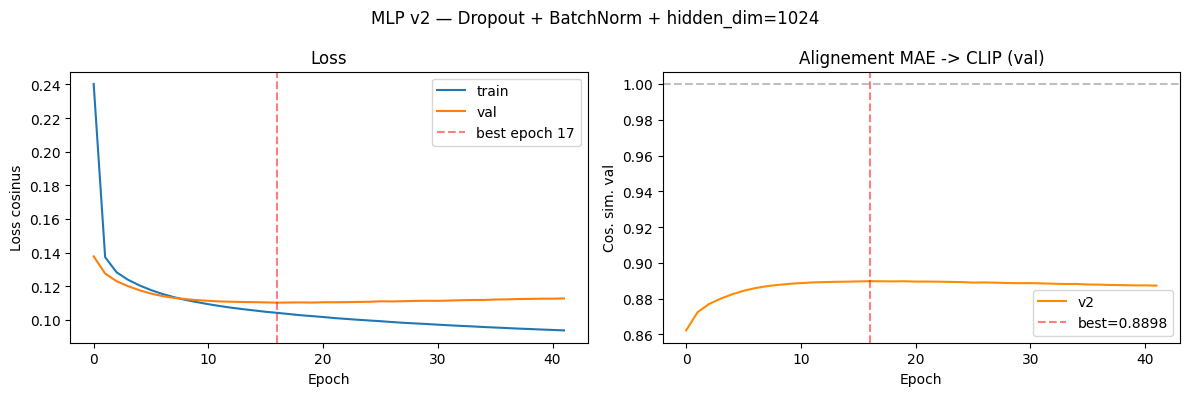

Gap train/val final : 0.0937 / 0.1127


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MLP v2 — Dropout + BatchNorm + hidden_dim=1024')

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss cosinus')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['val_cos_sim'], color='darkorange', label='v2')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos:.4f}')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cos. sim. val')
axes[1].set_title('Alignement MAE -> CLIP (val)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Gap train/val final : {history["train_loss"][-1]:.4f} / {history["val_loss"][-1]:.4f}')

### 3.5 Test d'inférence zero-shot sur un token patch

Chargement du meilleur modèle et test sur quelques exemples pour vérifier que la projection fonctionne qualitativement.

In [5]:
import json

# Charger le meilleur modele
model.load_state_dict(torch.load('projection_mlpv2_best.pt'))
model.eval()

# Charger les stats de normalisation
norm_stats = torch.load('z_full_norm_stats.pt')
z_mean = norm_stats['mean']
z_std = norm_stats['std']

# Charger les 100 classes ImageNet-100
with open('imagenet100-hf/label2text.json') as f:
    label2text = json.load(f)

# Vocabulaire de concepts textuels : toutes les 100 classes
CONCEPTS = [f'a photo of a {name}' for name in label2text.values()]

print(f'{len(CONCEPTS)} concepts charges')
print('Exemples :', CONCEPTS[:5])
print('Si clip_model n est pas en memoire, relancer la cellule de generation du notebook 1 d abord')

100 concepts charges
Exemples : ['a photo of a bittern', 'a photo of a conch', 'a photo of a indigo bunting', 'a photo of a hornbill', 'a photo of a bee eater']
Si clip_model n est pas en memoire, relancer la cellule de generation du notebook 1 d abord


In [8]:
import os
from transformers import CLIPProcessor, CLIPModel

# Recharger CLIP si necessaire (notebook 1 le supprime apres generation)
try:
    clip_model
    clip_processor
    print('CLIP deja en memoire')
except NameError:
    CLIP_PATH = './clip-vit-large-patch14' if os.path.exists('./clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'
    clip_model = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
    clip_model.eval()
    print('CLIP recharge')

# Encoder les 100 concepts textuels
text_inputs = clip_processor(text=CONCEPTS, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
    text_features = clip_model.get_text_features(**text_inputs)
text_features = F.normalize(text_features.float(), dim=-1)  # (100, 768)
print(f'Text features : {text_features.shape}')

# Charger quelques exemples du val set avec leurs labels
N_SAMPLES = 10
data_val_raw = torch.load('pairs_val.pt')
z_full_samples = data_val_raw['z_full'][:N_SAMPLES]
z_clip_samples = data_val_raw['z_clip'][:N_SAMPLES]
labels_samples = data_val_raw['labels'][:N_SAMPLES]

# Normaliser z_full avec les stats du train
z_full_norm = (z_full_samples - z_mean) / z_std

# Projeter avec le MLP
with torch.no_grad():
    z_proj = model(z_full_norm.to(DEVICE))  # (N, 768)

# Similarites cosinus
sims_proj = z_proj @ text_features.T  # (N, 100)
sims_clip = z_clip_samples.to(DEVICE) @ text_features.T  # (N, 100) oracle

TOP_K = 3
correct_top1 = 0
print(f'\n{"="*60}')
for i in range(N_SAMPLES):
    true_idx = labels_samples[i].item()
    true_name = label2text[str(true_idx)]

    top_proj_idx = sims_proj[i].topk(TOP_K).indices.tolist()
    top_clip_idx = sims_clip[i].topk(TOP_K).indices.tolist()

    pred_names = [label2text[str(j)] for j in top_proj_idx]
    oracle_names = [label2text[str(j)] for j in top_clip_idx]

    match = (true_idx == top_proj_idx[0])
    if match:
        correct_top1 += 1

    print(f'Sample {i+1} — Vraie classe : {true_name}')
    print(f'  MLP  top-{TOP_K}: {pred_names}  {"OK" if match else "X"}')
    print(f'  CLIP top-{TOP_K}: {oracle_names}')
    print()

print(f'Top-1 accuracy sur {N_SAMPLES} exemples : {correct_top1}/{N_SAMPLES}')

CLIP deja en memoire
Text features : torch.Size([100, 768])

Sample 1 — Vraie classe : white stork
  MLP  top-3: ['drake', 'crane', 'spoonbill']  X
  CLIP top-3: ['white stork', 'bustard', 'crane']

Sample 2 — Vraie classe : rooster
  MLP  top-3: ['drake', 'peacock', 'goose']  X
  CLIP top-3: ['rooster', 'hen', 'drake']

Sample 3 — Vraie classe : bald eagle
  MLP  top-3: ['drake', 'kite', 'bulbul']  X
  CLIP top-3: ['bald eagle', 'drake', 'American coot']

Sample 4 — Vraie classe : vine snake
  MLP  top-3: ['vine snake', 'green snake', 'green mamba']  OK
  CLIP top-3: ['vine snake', 'green snake', 'green mamba']

Sample 5 — Vraie classe : flatworm
  MLP  top-3: ['drake', 'rock crab', 'chiton']  X
  CLIP top-3: ['flatworm', 'sea slug', 'electric ray']

Sample 6 — Vraie classe : green lizard
  MLP  top-3: ['green lizard', 'common iguana', 'agama']  OK
  CLIP top-3: ['green lizard', 'common iguana', 'green mamba']

Sample 7 — Vraie classe : whiptail
  MLP  top-3: ['drake', 'whiptail', 'co